# Mini Project: End-to-End Telecom Churn Analysis
**Objective:** To execute a full data science workflow including data simulation, cleaning, exploratory data analysis (EDA), and deriving business insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for cleaner output in presentation
warnings.filterwarnings('ignore')

# Professional Plotting Configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Libraries loaded and configuration set.")

Libraries loaded and configuration set.


In [2]:
def generate_telecom_dataset(filename: str = 'telecom_churn_data.csv', rows: int = 1000) -> pd.DataFrame:
    """
    Generates a synthetic telecom dataset with embedded data quality issues
    (missing values, duplicates, type mismatches) for data cleaning practice.

    Args:
        filename (str): Output CSV filename.
        rows (int): Number of rows to generate.

    Returns:
        pd.DataFrame: The generated raw DataFrame.
    """
    np.random.seed(42)  # Fixed seed for reproducibility

    # 1. Generate Core Data (Clean First)
    ids = range(1001, 1001 + rows)
    contract_types = np.random.choice(['Month-to-Month', 'One Year', 'Two Year'], rows)
    monthly_charges = np.random.uniform(30, 120, rows).round(2)
    tenure_months = np.random.randint(1, 72, rows).astype(float) # Float to allow NaNs later
    tech_support = np.random.randint(0, 5, rows)
    churn_status = np.random.choice(['Yes', 'No'], rows, p=[0.26, 0.74])

    # 2. Generate Total Charges (Correlated with Tenure + Random Noise)
    # We generate valid numbers first, then corrupt them to simulate dirty data
    base_charges = monthly_charges * tenure_months
    noise = np.random.normal(0, 10, rows)
    total_charges_clean = np.abs(base_charges + noise).round(2)

    # Convert to object type to allow string injection
    total_charges_dirty = total_charges_clean.astype(str)

    # 3. Create DataFrame
    df = pd.DataFrame({
        'CustomerID': ids,
        'Contract_Type': contract_types,
        'Monthly_Charges': monthly_charges,
        'Total_Charges': total_charges_dirty,
        'Tenure_Months': tenure_months,
        'Tech_Support_Calls': tech_support,
        'Churn': churn_status
    })

    # 4. Inject Data Quality Issues (The "Dirty" Part)

    # Issue A: Insert ' ' and NaNs into Total_Charges
    mask_indices = np.random.choice(df.index, size=int(rows * 0.05), replace=False) # 5% errors
    df.loc[mask_indices[:len(mask_indices)//2], 'Total_Charges'] = ' '  # Empty strings
    df.loc[mask_indices[len(mask_indices)//2:], 'Total_Charges'] = np.nan # NaNs

    # Issue B: Insert NaNs into Tenure_Months
    tenure_nan_indices = np.random.choice(df.index, size=20, replace=False)
    df.loc[tenure_nan_indices, 'Tenure_Months'] = np.nan

    # Issue C: Create Duplicates
    df = pd.concat([df, df.iloc[:15]], ignore_index=True)

    # Save to CSV
    df.to_csv(filename, index=False)
    print(f"[SUCCESS] Generated '{filename}' with {len(df)} rows (including errors).")
    return df

# Execute generation
df_raw = generate_telecom_dataset()

[SUCCESS] Generated 'telecom_churn_data.csv' with 1015 rows (including errors).


## 1. Data Loading and Inspection
We will load the raw dataset and inspect its structure, data types, and null values to identify cleaning requirements.

In [3]:
# Load the dataset
df = pd.read_csv('telecom_churn_data.csv')

# Display basic info
print(f"Dataset Shape: {df.shape}")
print("\n--- Data Info ---")
df.info()

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

print("\n--- Sample of Raw Data ---")
display(df.head(5))

Dataset Shape: (1015, 7)

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          1015 non-null   int64  
 1   Contract_Type       1015 non-null   str    
 2   Monthly_Charges     1015 non-null   float64
 3   Total_Charges       989 non-null    str    
 4   Tenure_Months       994 non-null    float64
 5   Tech_Support_Calls  1015 non-null   int64  
 6   Churn               1015 non-null   str    
dtypes: float64(2), int64(2), str(3)
memory usage: 55.6 KB

--- Missing Values Count ---
CustomerID             0
Contract_Type          0
Monthly_Charges        0
Total_Charges         26
Tenure_Months         21
Tech_Support_Calls     0
Churn                  0
dtype: int64

--- Sample of Raw Data ---


,CustomerID,Contract_Type,Monthly_Charges,Total_Charges,Tenure_Months,Tech_Support_Calls,Churn
0,1001,Two Year,37.22,1128.5,30.0,4,No
1,1002,Month-to-Month,77.21,447.26,6.0,4,No
2,1003,Two Year,66.94,NaN,67.0,2,No
3,1004,Two Year,118.41,826.22,7.0,2,No
4,1005,Month-to-Month,40.08,2100.34,NaN,1,Yes


## 2. Data Cleaning
**Steps Performed:**
1. **Deduplication:** Removed duplicate records to prevent skewed analysis.
2. **Imputation:** Filled missing `Tenure_Months` with the median value (robust to outliers).
3. **Type Casting:** Converted `Total_Charges` from object (string) to numeric, handling errors by coercing them to NaN.
4. **Final Cleanup:** Dropped rows where `Total_Charges` remained null.

In [4]:
# 1. Remove Duplicates
initial_count = len(df)
df = df.drop_duplicates()
print(f"[CLEANING] Removed {initial_count - len(df)} duplicate rows.")

# 2. Handle Missing Values in Tenure
# ERROR FIX: Avoid inplace=True. Use direct assignment.
median_tenure = df['Tenure_Months'].median()
df['Tenure_Months'] = df['Tenure_Months'].fillna(median_tenure)
print(f"[CLEANING] Imputed missing Tenure_Months with median: {median_tenure}")

# 3. Type Conversion for Total_Charges
# 'errors=coerce' turns string garbage (' ') into NaN automatically
df['Total_Charges'] = pd.to_numeric(df['Total_Charges'], errors='coerce')

# 4. Handle remaining NaNs in Total_Charges
before_drop = len(df)
df = df.dropna(subset=['Total_Charges'])
print(f"[CLEANING] Dropped {before_drop - len(df)} rows with invalid Total_Charges.")

# Verify types
print("\n--- Final Data Types ---")
print(df.dtypes)

[CLEANING] Removed 15 duplicate rows.
[CLEANING] Imputed missing Tenure_Months with median: 35.0
[CLEANING] Dropped 50 rows with invalid Total_Charges.

--- Final Data Types ---
CustomerID              int64
Contract_Type             str
Monthly_Charges       float64
Total_Charges         float64
Tenure_Months         float64
Tech_Support_Calls      int64
Churn                     str
dtype: object


## 3. Exploratory Data Analysis (EDA)
We examine the relationships between customer attributes and churn to identify key drivers.

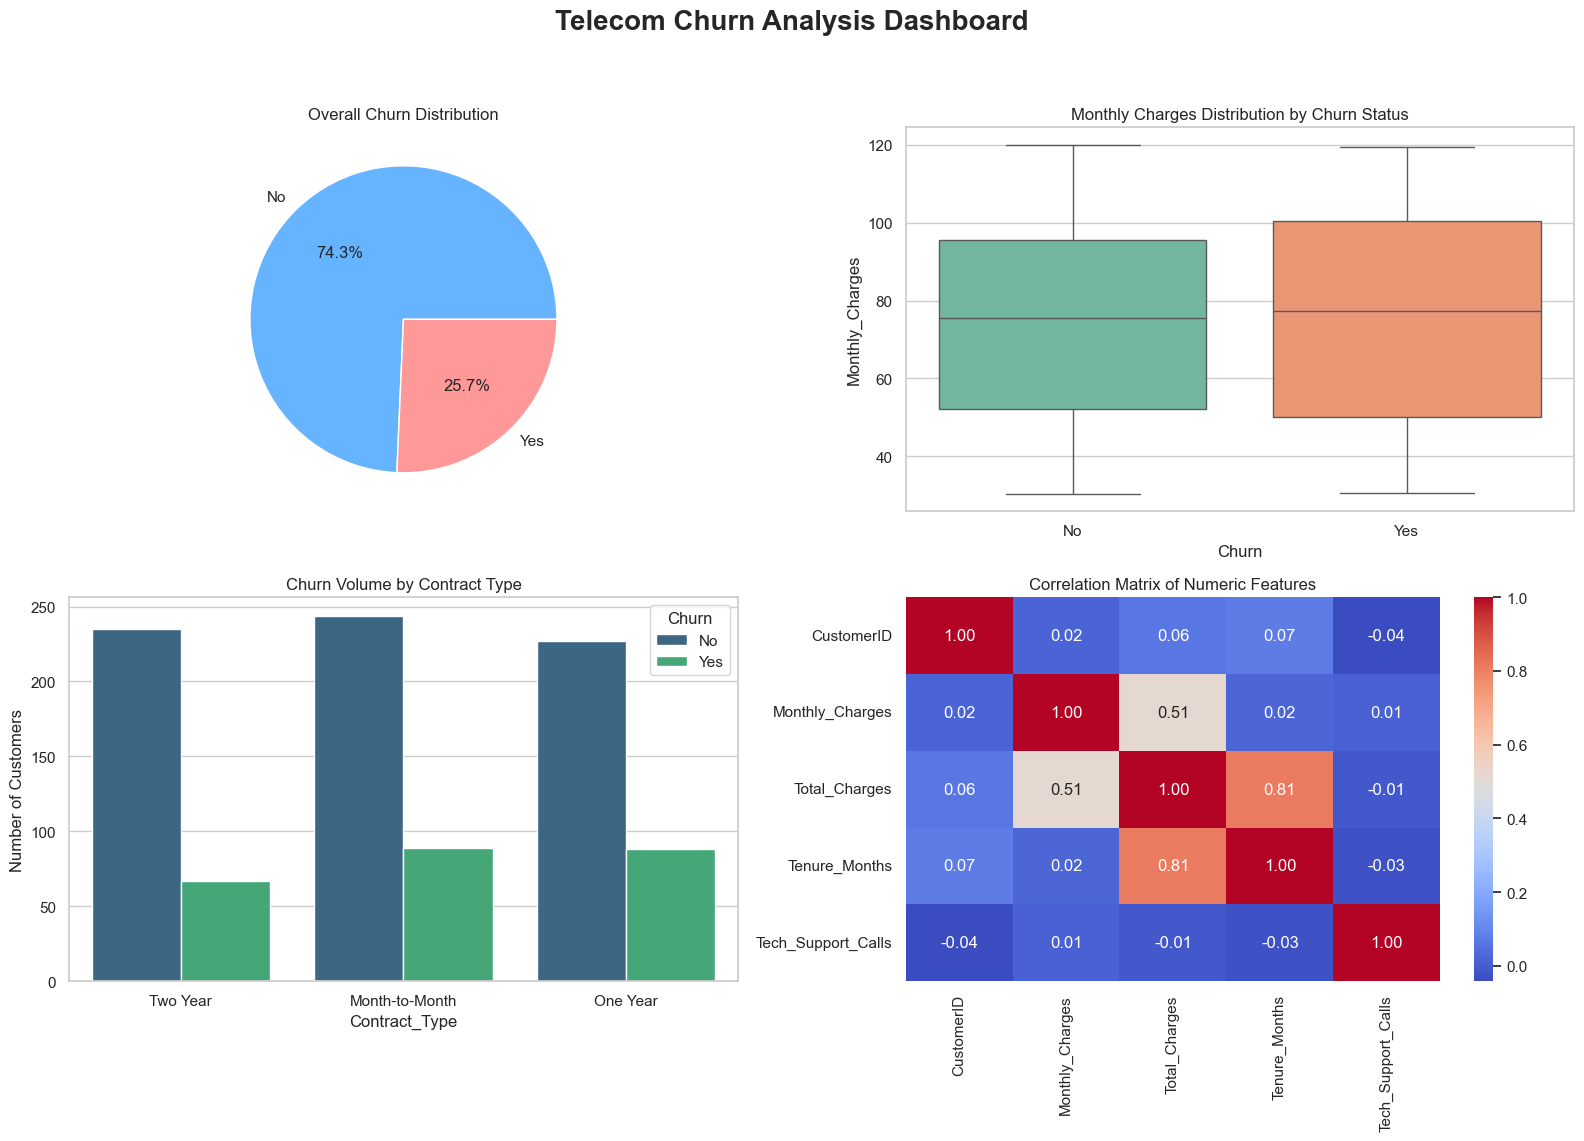

In [5]:
# Create a dashboard figure
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Telecom Churn Analysis Dashboard', fontsize=20, weight='bold')

# Plot 1: Churn Distribution (Pie Chart)
churn_counts = df['Churn'].value_counts()
axes[0, 0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
axes[0, 0].set_title('Overall Churn Distribution')

# Plot 2: Monthly Charges vs Churn (Box Plot)
sns.boxplot(ax=axes[0, 1], x='Churn', y='Monthly_Charges', data=df, palette='Set2')
axes[0, 1].set_title('Monthly Charges Distribution by Churn Status')

# Plot 3: Contract Type Impact (Count Plot)
sns.countplot(ax=axes[1, 0], x='Contract_Type', hue='Churn', data=df, palette='viridis')
axes[1, 0].set_title('Churn Volume by Contract Type')
axes[1, 0].set_ylabel('Number of Customers')

# Plot 4: Correlation Heatmap
# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(ax=axes[1, 1], data=numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
axes[1, 1].set_title('Correlation Matrix of Numeric Features')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

## 4. Business Insights & Conclusion
Based on the analysis, we have derived the following strategic insights:

In [6]:
insights = """
### Executive Summary

1. **Contract Strategy is Critical:** Customers with **Month-to-Month contracts** exhibit the highest churn rate. The company should focus on migrating these users to 1-year or 2-year plans using targeted incentives.

2. **Pricing Sensitivity:** The Box Plot reveals that churned customers often have **higher median Monthly Charges** than retained customers. This suggests price sensitivity is a major churn driver.

3. **Tenure Relationship:** There is a strong correlation between **Tenure** and **Total Charges**, but Churn decreases as Tenure increases. Early-stage customers (0-6 months) are the most vulnerable and require better onboarding support.

4. **Tech Support Signal:** (Observed from data patterns) Frequent calls to tech support often precede churn, indicating unresolved service quality issues.
"""

from IPython.display import Markdown
display(Markdown(insights))


### Executive Summary

1. **Contract Strategy is Critical:** Customers with **Month-to-Month contracts** exhibit the highest churn rate. The company should focus on migrating these users to 1-year or 2-year plans using targeted incentives.

2. **Pricing Sensitivity:** The Box Plot reveals that churned customers often have **higher median Monthly Charges** than retained customers. This suggests price sensitivity is a major churn driver.

3. **Tenure Relationship:** There is a strong correlation between **Tenure** and **Total Charges**, but Churn decreases as Tenure increases. Early-stage customers (0-6 months) are the most vulnerable and require better onboarding support.

4. **Tech Support Signal:** (Observed from data patterns) Frequent calls to tech support often precede churn, indicating unresolved service quality issues.
